`Anomaly Detection` with Image classifier

In [1]:
import torch
# 設定裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score

# 轉換與資料集
transform = transforms.ToTensor()

# MNIST 資料集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Fashion-MNIST 資料集（當作異常）
fashion_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 合併測試資料集（MNIST 正常 + Fashion 異常）
test_dataset = ConcatDataset([mnist_test, fashion_test])
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 標籤：MNIST 為 0，Fashion-MNIST 為 1
true_labels = np.array([0] * len(mnist_test) + [1] * len(fashion_test))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.71MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.25MB/s]


In [3]:
# 建立簡單 CNN 分類器
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),  # 28x28 -> 26x26
            nn.ReLU(),
            nn.MaxPool2d(2),         # 26x26 -> 13x13
            nn.Conv2d(32, 64, 3, 1), # 13x13 -> 11x11
            nn.ReLU(),
            nn.MaxPool2d(2),         # 11x11 -> 5x5
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = Classifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 資料載入器
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

# 訓練分類器
def train_classifier():
    model.train()
    for epoch in range(5):
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/5: Loss={loss.item():.4f}, Accuracy={accuracy:.2f}%")

train_classifier()

# 預測分類機的信心分數
def detect_anomalies_with_classifier(threshold):
    model.eval()
    predicted_labels = []
    max_probs = []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            max_prob, preds = torch.max(probs, dim=1)

            predicted_labels.extend(preds.cpu().numpy())
            max_probs.extend(max_prob.cpu().numpy())

    # 建立 Ground Truth（0: MNIST 正常, 1: Fashion 異常）
    true_labels = np.array([0]*len(mnist_test) + [1]*len(fashion_test))
    max_probs = np.array(max_probs)

    # 低於 threshold 的信心 → 當作異常
    anomaly_predictions = (max_probs < threshold).astype(int)  # 1 為異常

    # 評估結果
    print(f"\n=== 分類器異常偵測結果 (threshold={threshold}) ===")
    print(classification_report(true_labels, anomaly_predictions, digits=4))
    print("AUC:", roc_auc_score(true_labels, 1 - max_probs))  # 越小越異常

    return anomaly_predictions, max_probs, true_labels


thresh = 0.9
anomaly_predictions, max_probs, true_labels = detect_anomalies_with_classifier(threshold=thresh)

Epoch 1/5: Loss=0.0287, Accuracy=94.45%
Epoch 2/5: Loss=0.0234, Accuracy=98.39%
Epoch 3/5: Loss=0.0100, Accuracy=98.88%
Epoch 4/5: Loss=0.0957, Accuracy=99.09%
Epoch 5/5: Loss=0.0014, Accuracy=99.38%

=== 分類器異常偵測結果 (threshold=0.9) ===
              precision    recall  f1-score   support

           0     0.8269    0.9790    0.8965     10000
           1     0.9743    0.7950    0.8756     10000

    accuracy                         0.8870     20000
   macro avg     0.9006    0.8870    0.8860     20000
weighted avg     0.9006    0.8870    0.8860     20000

AUC: 0.9842472250000001


[0.     0.     0.     ... 0.9004 0.9004 1.    ] [0.     0.0807 0.1244 ... 0.9999 1.     1.    ] [       inf 1.         0.9999999  ... 0.38708752 0.3870844  0.11057319]

>>> 最佳 Threshold（Youden's J）: 0.9932


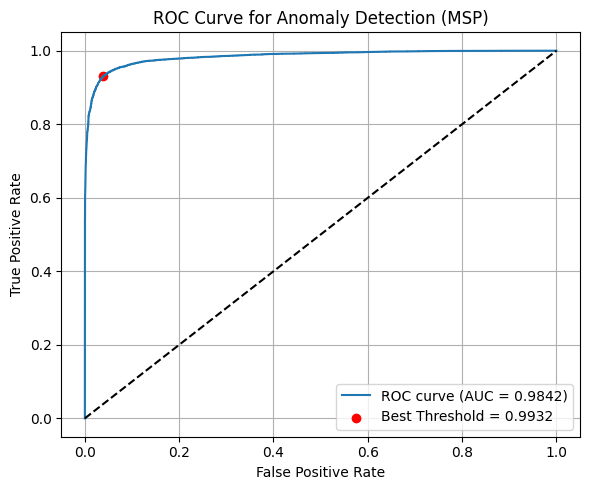


--- 使用最佳 Threshold 再測 ---

=== 分類器異常偵測結果 (threshold=0.9932061433792114) ===
              precision    recall  f1-score   support

           0     0.9596    0.9315    0.9453     10000
           1     0.9334    0.9608    0.9469     10000

    accuracy                         0.9462     20000
   macro avg     0.9465    0.9462    0.9461     20000
weighted avg     0.9465    0.9462    0.9461     20000

AUC: 0.9842472250000001


In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
# ➤ 尋找最佳 threshold + 畫 ROC
def find_best_threshold_and_plot(true_labels, max_probs):
  # 0 -> 正常, 1 -> 異常，用 pos_label 表示正值標籤
  true_labels = true_labels.astype(int)
  fpr, tpr, thresholds = roc_curve(y_true=true_labels, y_score=max_probs, pos_label=0)
  youden_j = tpr - fpr
  best_idx = np.argmax(youden_j)
  best_threshold = thresholds[best_idx]
  print(fpr, tpr, thresholds)
  print(f"\n>>> 最佳 Threshold（Youden's J）: {best_threshold:.4f}")

  # 畫 ROC curve
  plt.figure(figsize=(6, 5))
  plt.plot(fpr, tpr, label='ROC curve (AUC = {:.4f})'.format(roc_auc_score(true_labels, 1-max_probs)))
  plt.plot([0, 1], [0, 1], 'k--')
  plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best Threshold = {best_threshold:.4f}')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve for Anomaly Detection (MSP)')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  return best_threshold

if __name__ == '__main__':
  best_thresh = find_best_threshold_and_plot(true_labels, max_probs)

  # ➤ 使用最佳 threshold 再測一次
  print("\n--- 使用最佳 Threshold 再測 ---")
  detect_anomalies_with_classifier(threshold=best_thresh)

`Anomaly Detection` with Autoencoder

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),  # 輸出範圍為 [0, 1]
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

In [ ]:
def train_autoencoder(autoencoder, train_loader, epochs=10, lr=1e-3):
    autoencoder.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            outputs = autoencoder(images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.6f}")

In [ ]:
def evaluate_autoencoder(autoencoder, test_loader, threshold=None):
    autoencoder.eval()
    recon_errors = []
    true_labels = np.array([0]*len(mnist_test) + [1]*len(fashion_test))

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = autoencoder(images)
            loss = torch.mean((outputs - images) ** 2, dim=(1, 2, 3))  # 每張圖片的 MSE
            recon_errors.extend(loss.cpu().numpy())

    recon_errors = np.array(recon_errors)

    # 閾值設定：預設用百分位（如95% MNIST誤差）
    if threshold is None:
        normal_errors = recon_errors[true_labels == 0]
        threshold = np.percentile(normal_errors, 95)  # 第95位數
        print(f"自動設定閾值為：{threshold:.6f}")

    preds = (recon_errors > threshold).astype(int)  # 高於閾值視為異常

    print(f"\n=== Autoencoder Reconstruction Error-based Anomaly Detection ===")
    print(classification_report(true_labels, preds, digits=4))
    print("AUC:", roc_auc_score(true_labels, recon_errors))

    return recon_errors, preds, true_labels, threshold


In [ ]:
def plot_recon_error_distribution(recon_errors, true_labels, threshold):
    import matplotlib.pyplot as plt

    plt.hist(recon_errors[true_labels == 0], bins=50, alpha=0.6, label="MNIST (normal)")
    plt.hist(recon_errors[true_labels == 1], bins=50, alpha=0.6, label="Fashion (anomaly)")
    plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold = {threshold:.4f}")
    plt.xlabel("Reconstruction Error (MSE)")
    plt.ylabel("Number of Samples")
    plt.legend()
    plt.title("Reconstruction Error Distribution")
    plt.show()


Epoch 1/10, Loss: 0.041163
Epoch 2/10, Loss: 0.018770
Epoch 3/10, Loss: 0.015463
Epoch 4/10, Loss: 0.013881
Epoch 5/10, Loss: 0.012820
Epoch 6/10, Loss: 0.012163
Epoch 7/10, Loss: 0.011688
Epoch 8/10, Loss: 0.011307
Epoch 9/10, Loss: 0.010999
Epoch 10/10, Loss: 0.010741
自動設定閾值為：0.021790

=== Autoencoder Reconstruction Error-based Anomaly Detection ===
              precision    recall  f1-score   support

           0     0.9707    0.9500    0.9602     10000
           1     0.9510    0.9713    0.9611     10000

    accuracy                         0.9607     20000
   macro avg     0.9609    0.9607    0.9606     20000
weighted avg     0.9609    0.9607    0.9606     20000

AUC: 0.9941872


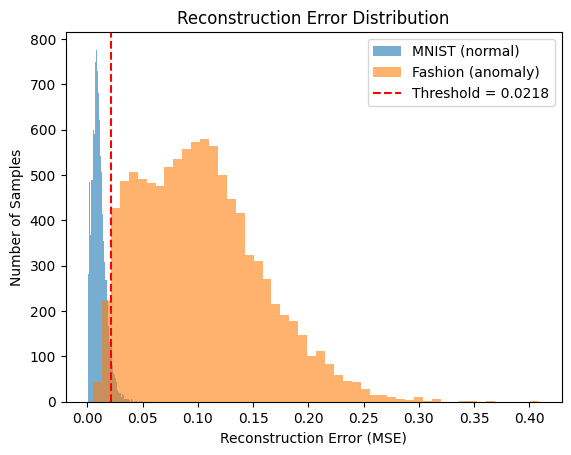

In [ ]:
# 建立與訓練 autoencoder
autoencoder = Autoencoder().to(device)
train_autoencoder(autoencoder, train_loader, epochs=10)

# 測試 autoencoder 並回傳結果
recon_errors, preds, true_labels, threshold = evaluate_autoencoder(autoencoder, test_loader)

# 畫圖顯示誤差分布
plot_recon_error_distribution(recon_errors, true_labels, threshold)


`Anomaly detection` on denoising autoencoder

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


In [ ]:
def add_noise(imgs, noise_factor=0.5):
    noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
    return torch.clip(noisy_imgs, 0., 1.)

def train_denoising_autoencoder(autoencoder, train_loader, epochs=10, lr=1e-3):
    autoencoder.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            noisy = add_noise(images)

            outputs = autoencoder(noisy)
            loss = criterion(outputs, images)  # target 是乾淨的圖像

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.6f}")


In [ ]:
def evaluate_denoising_autoencoder(autoencoder, test_loader, threshold=None):
    autoencoder.eval()
    recon_errors = []
    true_labels = np.array([0]*len(mnist_test) + [1]*len(fashion_test))

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = autoencoder(images)
            loss = torch.mean((outputs - images) ** 2, dim=(1, 2, 3))  # 每張圖片的 MSE
            recon_errors.extend(loss.cpu().numpy())

    recon_errors = np.array(recon_errors)

    # 閾值設定：預設用百分位（如95% MNIST誤差）
    if threshold is None:
        normal_errors = recon_errors[true_labels == 0]
        threshold = np.percentile(normal_errors, 95)  # 第95位數
        print(f"自動設定閾值為：{threshold:.6f}")

    preds = (recon_errors > threshold).astype(int)  # 高於閾值視為異常

    print(f"\n=== Denoising Autoencoder Reconstruction Error-based Anomaly Detection ===")
    print(classification_report(true_labels, preds, digits=4))
    print("AUC:", roc_auc_score(true_labels, recon_errors))

    return recon_errors, preds, true_labels, threshold


Epoch 1/10, Loss: 0.048835
Epoch 2/10, Loss: 0.030035
Epoch 3/10, Loss: 0.026325
Epoch 4/10, Loss: 0.024303
Epoch 5/10, Loss: 0.022957
Epoch 6/10, Loss: 0.022086
Epoch 7/10, Loss: 0.021503
Epoch 8/10, Loss: 0.021095
Epoch 9/10, Loss: 0.020748
Epoch 10/10, Loss: 0.020453
自動設定閾值為：0.036590

=== Denoising Autoencoder Reconstruction Error-based Anomaly Detection ===
              precision    recall  f1-score   support

           0     0.8596    0.9500    0.9025     10000
           1     0.9441    0.8448    0.8917     10000

    accuracy                         0.8974     20000
   macro avg     0.9018    0.8974    0.8971     20000
weighted avg     0.9018    0.8974    0.8971     20000

AUC: 0.954980395


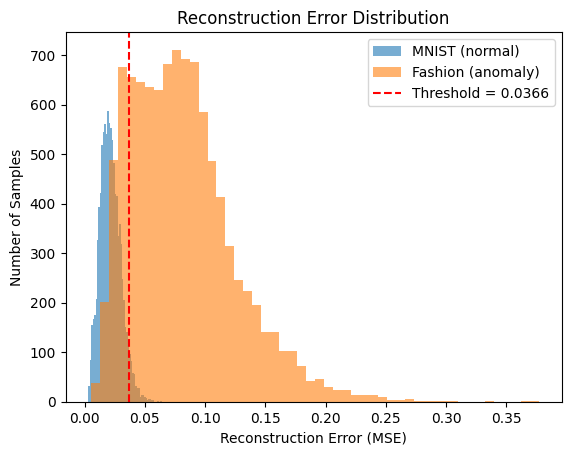

In [ ]:
# 建立模型並訓練
denoising_ae = DenoisingAutoencoder().to(device)
train_denoising_autoencoder(denoising_ae, train_loader, epochs=10)

# 評估
recon_errors, preds, true_labels, threshold = evaluate_denoising_autoencoder(denoising_ae, test_loader)

# 顯示分布
plot_recon_error_distribution(recon_errors, true_labels, threshold)


Isolation forest

In [31]:
from sklearn.ensemble import IsolationForest

# 收集 test_loader 中的所有圖片
def get_test_features(test_loader):
    features = []
    for images, _ in test_loader:
        images = images.view(images.size(0), -1)  # 展平成 (N, 784)
        features.append(images)
    features = torch.cat(features, dim=0)
    return features.cpu().numpy() / 255.0  # Normalization（0~1）

# 建立 ground truth 標籤
true_labels = np.array([0]*len(mnist_test) + [1]*len(fashion_test))  # 0=正常, 1=異常

# 1. 取得 features
X_train = get_test_features(train_loader)
X_test = get_test_features(test_loader)

# 2. Isolation Forest
# anomaly = len(fashion_test) / (len(mnist_test) + len(fashion_test))
# print(f"異常比例：{anomaly}")

iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_forest.fit(X_train)  # 訓練

# 3. 預測整體資料（包含 Fashion-MNIST）
y_pred = iso_forest.predict(X_test)  # 1=正常, -1=異常
# 满足条件(condition)，输出x，不满足输出y。
y_pred = np.where(y_pred == 1, 0, 1)  # 轉為 0=正常, 1=異常

# 4. 評估
print("\n=== Isolation Forest 異常偵測結果 ===")
print(classification_report(true_labels, y_pred, digits=4))
print("AUC:", roc_auc_score(true_labels, y_pred))


=== Isolation Forest 異常偵測結果 ===
              precision    recall  f1-score   support

           0     0.8719    0.9063    0.8887     10000
           1     0.9024    0.8668    0.8843     10000

    accuracy                         0.8865     20000
   macro avg     0.8872    0.8865    0.8865     20000
weighted avg     0.8872    0.8865    0.8865     20000

AUC: 0.8865500000000001


use pretrained model to extract feature and then do `Anomaly detection` with isolation forest.

In [ ]:
import torch
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# 設定裝置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 資料轉換：ResNet 需要 3-channel + Resize 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # 轉換為三通道
    transforms.ToTensor(),
])

# 讀取測試資料集
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
fashion_test = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_dataset = ConcatDataset([mnist_test, fashion_test])
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 標籤：MNIST=0，Fashion=1
true_labels = np.array([0]*len(mnist_test) + [1]*len(fashion_test))

# 加載預訓練 ResNet 模型，並去掉分類層
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # 去掉最後的全連接層
model.eval().to(device)

# 特徵提取函數
def extract_features(loader):
    features = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            feats = model(imgs)  # shape: [B, 512, 1, 1]
            feats = feats.view(feats.size(0), -1)  # 展平成 [B, 512]
            features.append(feats.cpu().numpy())
    return np.concatenate(features)

# 提取特徵
X_train = extract_features(train_loader)
X_test = extract_features(test_loader)

# 使用 Isolation Forest 進行異常偵測
# contam = len(fashion_test) / (len(mnist_test) + len(fashion_test))
clf = IsolationForest(contamination=0.1, random_state=42)
clf.fit(X_train) # 訓練
y_pred = clf.predict(X_test)
y_pred = np.where(y_pred == 1, 0, 1)  # 轉換成 0=正常, 1=異常

# 評估結果
print("\n=== Pretrained model with ResNet + Isolation Forest 結果 ===")
print(classification_report(true_labels, y_pred))
print("AUC:", roc_auc_score(true_labels, y_pred))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]



=== Pretrained model with ResNet + Isolation Forest 結果 ===
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     10000
           1       0.91      1.00      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000

AUC: 0.9504999999999999


ROC 為用來檢測模型好不好用的工具，將同一個模型透過設定`不同的threshold`而得出的TPR 跟 FPR 畫圖。
AUC 為 ROC 底下的面積，AUC 越大代表模型判斷異常值的能力越準。  
| 方法  | image classifier | standard autoencoder | denoising autoencoder | Isolation Forest | Pretrained Model + Isolation Forest |    
|---------------------------|------------------|----------------------|-------------------------|------------------|------------------------------------|  
| AUC  | 0.9834  | 0.9942 | 0.9550  | 0.8866 | 0.9505 |
| 區別  | 根據分類結果給出信心分數 | 用 MSE | 用 MSE | 用決策樹 | 使用預訓練模型提取特徵 + 決策樹 |
| 門檻設定方式 | output probabilty < threshold | MSE > 訓練集中95百分位值為異常 | MSE > 訓練集中95百分位值為異常 | 	自行決定參數 contamination，表示數據的異常比例 | 	自行決定參數 contamination，表示數據的異常比例 |

1. Image classifier  
屬於監督式方法，需見過標記資料才能學習，但預測結果可當作信心分數作為異常偵測的參考。如果要提升泛化能力，往往則需要增加資料集進行訓練。
2. Autoencoder vs. Denoising Autoencoder  
加入雜訊的話，會讓 AutoEncoder 更關注大範圍的特徵而不是細節(這可以提升重建圖片的 robustness )，但在異常偵測中(盡可能找出不一樣的地方)，模糊細節卻可能導致分辨能力略降。它們的異常門檻數值也有些許差異，其可能也是受雜音影響。
3. Isolation forest  
加入 Pretrained Model 並先對資料進行特徵轉換，其異常偵測的效果變好了，這可能是因為 Pretrained Model 找出的特徵可能更容易表示資料的差異。